In [7]:
!pip install xgboost

In [8]:
import pandas as pd
import numpy as np

from xgboost import XGBRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

In [9]:
feature_matrix = pd.read_csv(
    r"C:\Users\cbala\OneDrive\Desktop\RecruitSmart\final_feature_set.csv"
)

feature_matrix.head()

,job_id,person_id,title,required_experience,total_skills,match_relevance_score
0,15796,20608,Beauty & Fragrance consultants needed,NaN,19,0.5
1,861,37600,Retail Territory Merchandiser,NaN,113,0.9
2,5391,51921,Inside Sales Rep,Associate,66,0.9
3,11965,28530,Cities Project Manager,NaN,26,0.5
4,11285,35955,Digital Procurement Assistant,Entry level,58,0.9


In [13]:
X = feature_matrix[["total_skills"]]

y = feature_matrix["match_relevance_score"]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [19]:
predictions = model.predict(X_test)

In [21]:
mae = mean_absolute_error(y_test, predictions)

print("MAE")

print(mae)

MAE
3.4691721200953704e-05


In [23]:
results = []

for depth in [3,5,7]:

    for lr in [0.01,0.1,0.2]:

        model = XGBRegressor(
            n_estimators=100,
            max_depth=depth,
            learning_rate=lr,
            random_state=42
        )

        model.fit(X_train,y_train)

        pred = model.predict(X_test)

        mae = mean_absolute_error(y_test,pred)

        results.append([depth,lr,mae])

In [25]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Max Depth",
        "Learning Rate",
        "MAE"
    ]
)

results_df

,Max Depth,Learning Rate,MAE
0,3,0.01,0.085912
1,3,0.10,0.000035
2,3,0.20,0.000030
3,5,0.01,0.085912
4,5,0.10,0.000035
5,5,0.20,0.000030
6,7,0.01,0.085912
7,7,0.10,0.000035
8,7,0.20,0.000030


In [27]:
results_df.sort_values(
    by="MAE"
).head()

,Max Depth,Learning Rate,MAE
2,3,0.2,0.000030
5,5,0.2,0.000030
8,7,0.2,0.000030
1,3,0.1,0.000035
4,5,0.1,0.000035


In [29]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":model.feature_importances_

})

importance

,Feature,Importance
0,total_skills,1.0


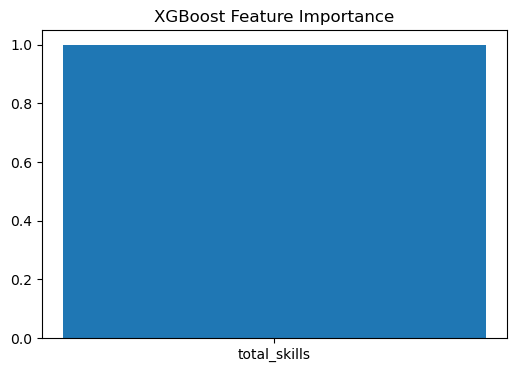

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.title("XGBoost Feature Importance")

plt.show()